In [1]:
import pandas as pd
df = pd.read_csv("3D Objects/Superstore-Sales-EDA-main/data/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df.shape

(9994, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe(include='object')


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


Data is fully cleaned. Let's Start EDA and Data Visualization

Count of each segment

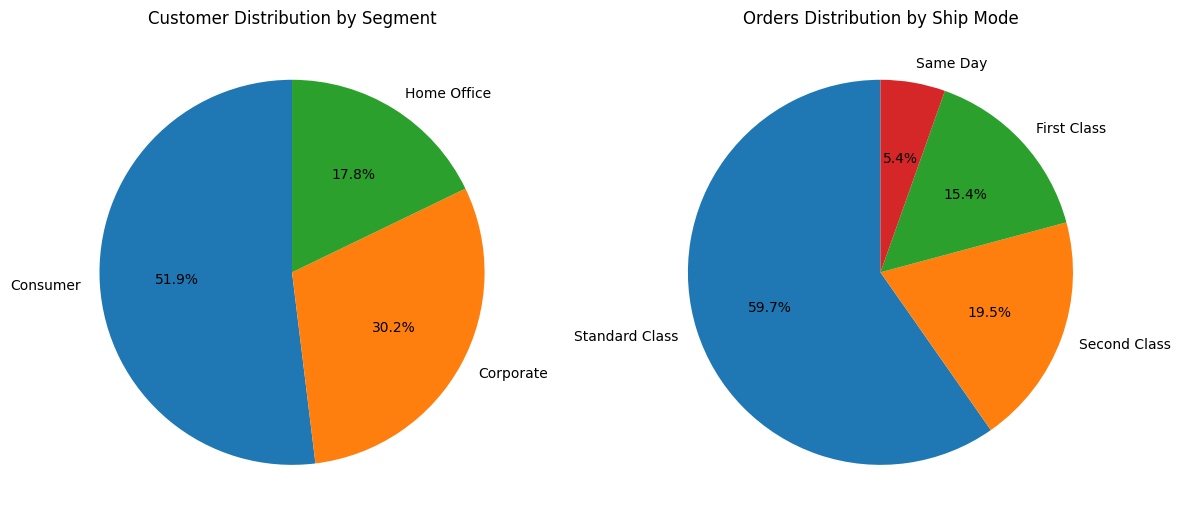

In [10]:
import matplotlib.pyplot as plt

# Count of each segment
segment_counts = df['Segment'].value_counts()

# Count of each ship mode
shipmode_counts = df['Ship Mode'].value_counts()

# Create figure with 2 subplots
plt.figure(figsize=(12, 6))

# Pie chart 1: Segment
plt.subplot(1, 2, 1)
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Customer Distribution by Segment')

# Pie chart 2: Ship Mode
plt.subplot(1, 2, 2)
plt.pie(
    shipmode_counts,
    labels=shipmode_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Orders Distribution by Ship Mode')

plt.tight_layout()
plt.show()


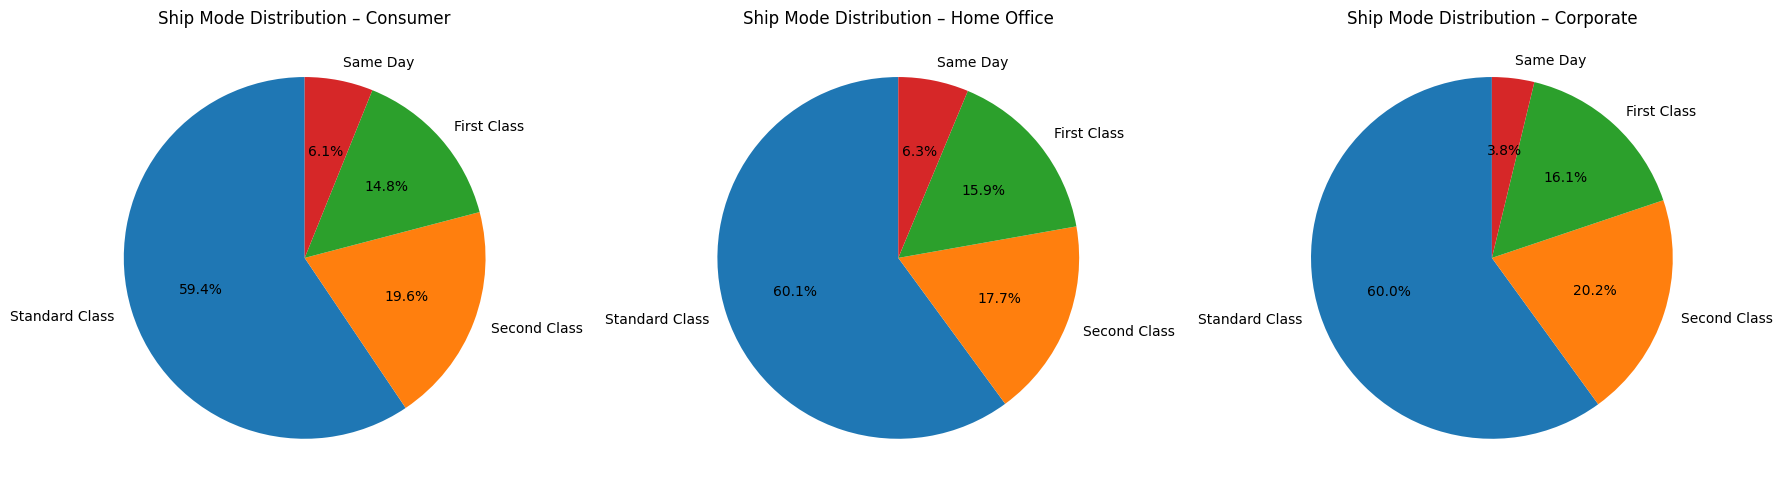

In [15]:
segments = ['Consumer', 'Home Office', 'Corporate']

plt.figure(figsize=(18, 6))

for i, segment in enumerate(segments, 1):
    segment_df = df[df['Segment'] == segment]
    shipmode_counts = segment_df['Ship Mode'].value_counts()

    plt.subplot(1, 3, i)
    plt.pie(
        shipmode_counts,
        labels=shipmode_counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f'Ship Mode Distribution – {segment}')

plt.tight_layout()
plt.show()


Sales and Profit Trend Over Time Monthly + Yearly

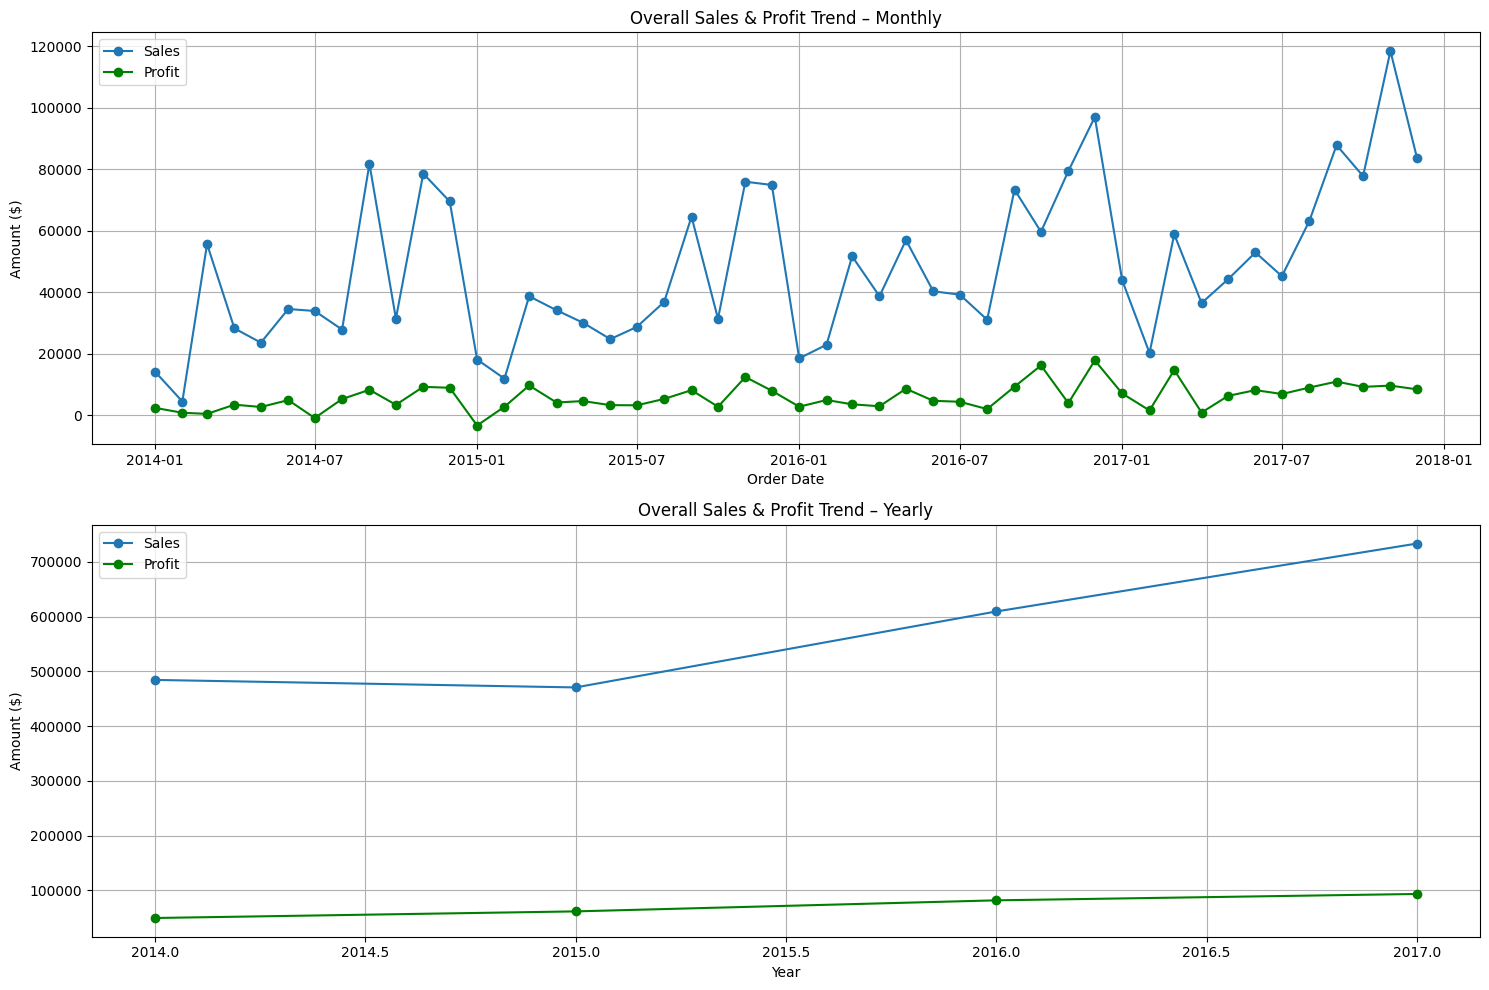

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Date preparation
# -----------------------------
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# -----------------------------
# 2. Aggregations
# -----------------------------
# Monthly
monthly_agg = (
    df.groupby('YearMonth')[['Sales', 'Profit']]
      .sum()
      .reset_index()
)
monthly_agg['YearMonth'] = monthly_agg['YearMonth'].dt.to_timestamp()

# Yearly
yearly_agg = (
    df.groupby('Year')[['Sales', 'Profit']]
      .sum()
      .reset_index()
)

# -----------------------------
# 3. Visualization
# -----------------------------
plt.figure(figsize=(15, 10))

# Monthly Trend
plt.subplot(2, 1, 1)
plt.plot(monthly_agg['YearMonth'], monthly_agg['Sales'], label='Sales', marker='o')
plt.plot(monthly_agg['YearMonth'], monthly_agg['Profit'], label='Profit', marker='o', color='green')
plt.title('Overall Sales & Profit Trend – Monthly')
plt.xlabel('Order Date')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True)

# Yearly Trend
plt.subplot(2, 1, 2)
plt.plot(yearly_agg['Year'], yearly_agg['Sales'], label='Sales', marker='o')
plt.plot(yearly_agg['Year'], yearly_agg['Profit'], label='Profit', marker='o', color='green')
plt.title('Overall Sales & Profit Trend – Yearly')
plt.xlabel('Year')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Last 12 Months Sales and Profit Trend + Outperforming Month

Top Performing Month: November 2017 | Sales = $118447.82 | Profit = $9690.10


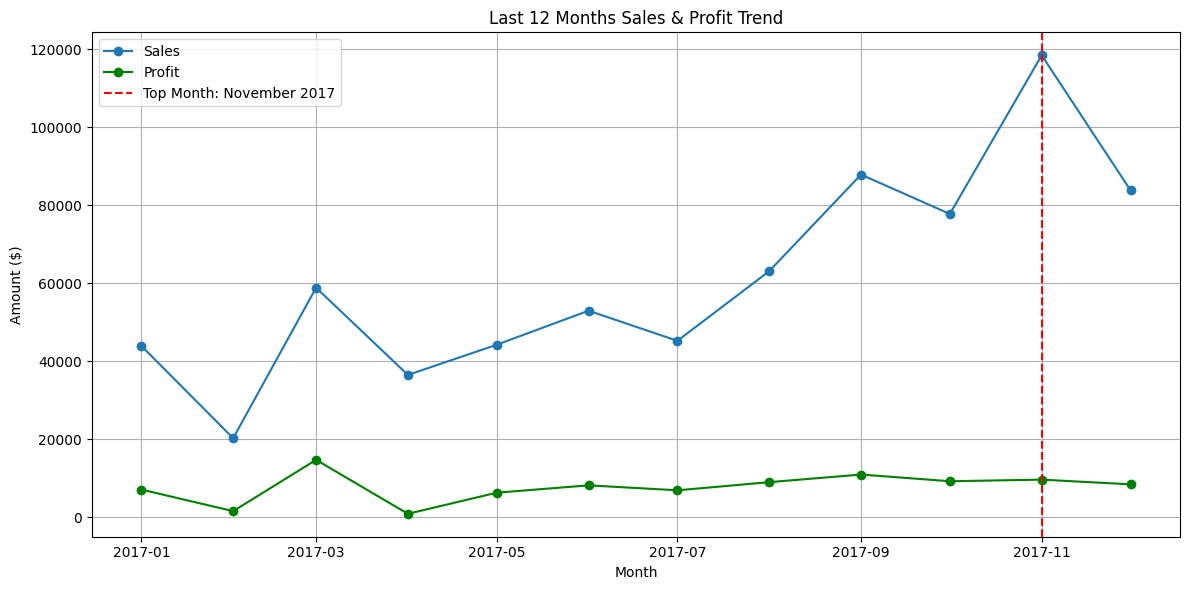

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Date preparation
# -----------------------------
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# -----------------------------
# 2. Filter last 12 months
# -----------------------------
last_12_df = df[df['YearMonth'] >= (df['YearMonth'].max() - 11)]

# Aggregate Sales and Profit
last_12_agg = (
    last_12_df.groupby('YearMonth')[['Sales', 'Profit']]
    .sum()
    .reset_index()
)
last_12_agg['YearMonth'] = last_12_agg['YearMonth'].dt.to_timestamp()

# -----------------------------
# 3. Identify top-performing month by Sales
# -----------------------------
top_month = last_12_agg.loc[last_12_agg['Sales'].idxmax()]
top_month_label = top_month['YearMonth'].strftime('%B %Y')

print(f"Top Performing Month: {top_month_label} | Sales = ${top_month['Sales']:.2f} | Profit = ${top_month['Profit']:.2f}")

# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure(figsize=(12, 6))

plt.plot(last_12_agg['YearMonth'], last_12_agg['Sales'], marker='o', label='Sales')
plt.plot(last_12_agg['YearMonth'], last_12_agg['Profit'], marker='o', label='Profit', color='green')

# Highlight top month
plt.axvline(top_month['YearMonth'], linestyle='--', color='red', label=f'Top Month: {top_month_label}')

plt.title('Last 12 Months Sales & Profit Trend')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Let's Check Sales and Profit by Category in November 2017 with Top Product per Category

=== Sales & Profit by Category ===
          Category      Sales     Profit
2       Technology  49918.773  5674.9371
0        Furniture  37056.715   406.0637
1  Office Supplies  31472.337  3609.1029

=== Top Product per Category ===
          Category                                    Product Name     Sales
0        Furniture                   Hon 94000 Series Round Tables   2665.62
1  Office Supplies  Hoover Shoulder Vac Commercial Portable Vacuum   2504.74
2       Technology           Canon imageCLASS 2200 Advanced Copier  10499.97


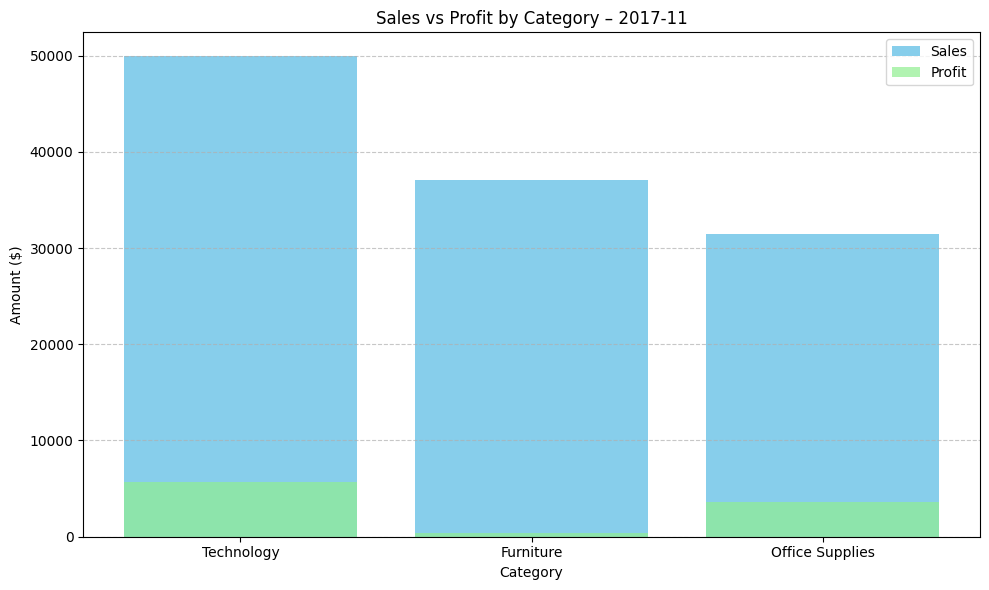

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Filter for November 2017
# -----------------------------
top_month = '2017-11'
top_month_df = df[df['Order Date'].dt.to_period('M') == pd.Period(top_month)]

# -----------------------------
# 2. Aggregate Sales and Profit by Category
# -----------------------------
category_agg = (
    top_month_df.groupby('Category')[['Sales', 'Profit']]
    .sum()
    .reset_index()
    .sort_values(by='Sales', ascending=False)
)

print("=== Sales & Profit by Category ===")
print(category_agg)

# -----------------------------
# 3. Find Top Product per Category
# -----------------------------
product_sales = (
    top_month_df.groupby(['Category', 'Sub-Category', 'Product Name'])['Sales']
    .sum()
    .reset_index()
    .sort_values(by='Sales', ascending=False)
)

top_products = product_sales.groupby('Category').first().reset_index()

print("\n=== Top Product per Category ===")
print(top_products[['Category', 'Product Name', 'Sales']])

# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure(figsize=(10, 6))

# Bar chart for Sales by Category
plt.bar(category_agg['Category'], category_agg['Sales'], color='skyblue', label='Sales')

# Overlay Profit
plt.bar(category_agg['Category'], category_agg['Profit'], color='lightgreen', label='Profit', alpha=0.7)

plt.title(f'Sales vs Profit by Category – {top_month}')
plt.ylabel('Amount ($)')
plt.xlabel('Category')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Regional Performance: Region → State → City

=== Sales & Profit by Region ===
    Region        Sales       Profit
3     West  725457.8245  108418.4489
1     East  678781.2400   91522.7800
0  Central  501239.8908   39706.3625
2    South  391721.9050   46749.4303


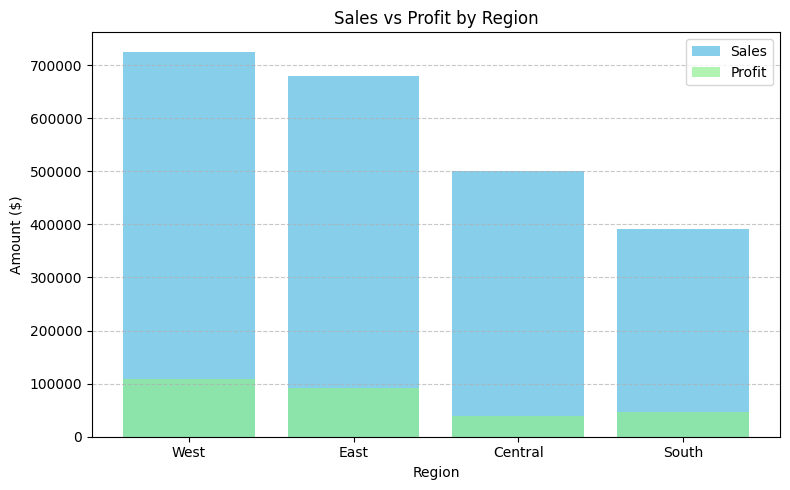

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Sales & Profit by Region
# -----------------------------
region_agg = (
    df.groupby('Region')[['Sales', 'Profit']]
    .sum()
    .reset_index()
    .sort_values(by='Sales', ascending=False)
)

print("=== Sales & Profit by Region ===")
print(region_agg)

# 4. Visualization: Region-level
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(region_agg['Region'], region_agg['Sales'], color='skyblue', label='Sales')
plt.bar(region_agg['Region'], region_agg['Profit'], color='lightgreen', alpha=0.7, label='Profit')
plt.title('Sales vs Profit by Region')
plt.ylabel('Amount ($)')
plt.xlabel('Region')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Top 10 States and Cities by Sales per Region

=== Top 10 States by Sales per Region ===
     Region           State        Sales      Profit
11  Central           Texas  170188.0458 -25729.3563
0   Central        Illinois   80166.1010 -12607.8870
4   Central        Michigan   76269.6140  24463.1876
1   Central         Indiana   53555.3600  18382.9363
12  Central       Wisconsin   32114.6100   8401.8004
5   Central       Minnesota   29863.1500  10823.1874
6   Central        Missouri   22205.1500   6436.2105
9   Central        Oklahoma   19683.3900   4853.9560
7   Central        Nebraska    7464.9300   2037.0942
2   Central            Iowa    4579.7600   1183.8119
21     East        New York  310876.2710  74038.5486
23     East    Pennsylvania  116511.9140 -15559.9603
22     East            Ohio   78258.1360 -16971.3766
20     East      New Jersey   35764.3120   9772.9138
18     East   Massachusetts   28634.4340   6785.5016
14     East        Delaware   27451.0690   9977.3748
17     East        Maryland   23705.5230   7031.1788
24  

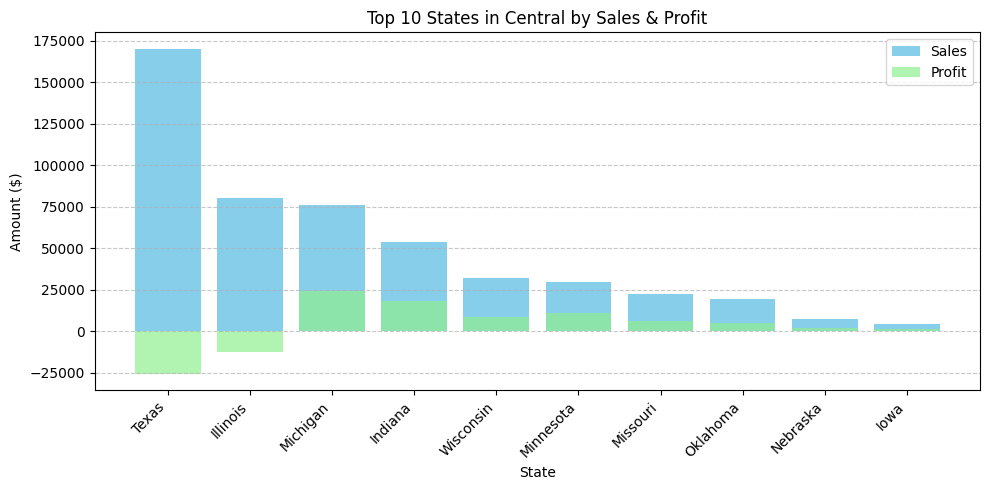

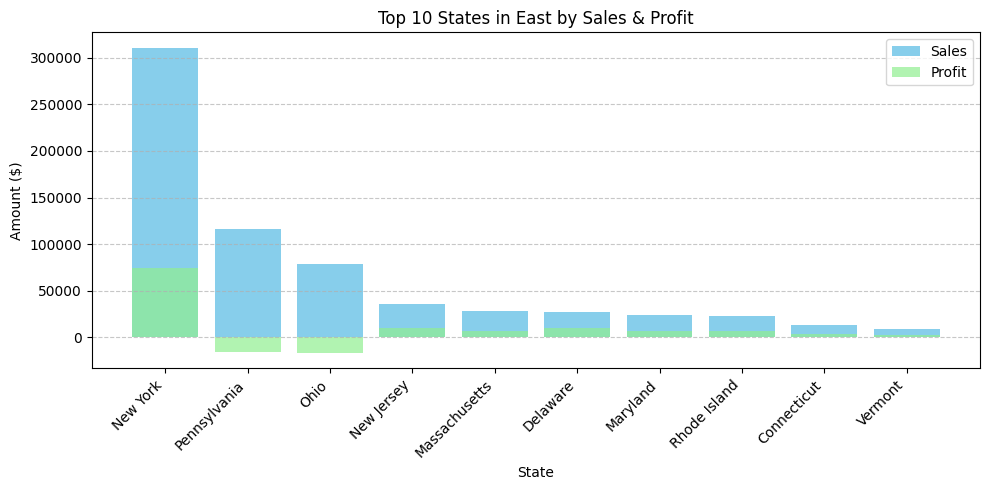

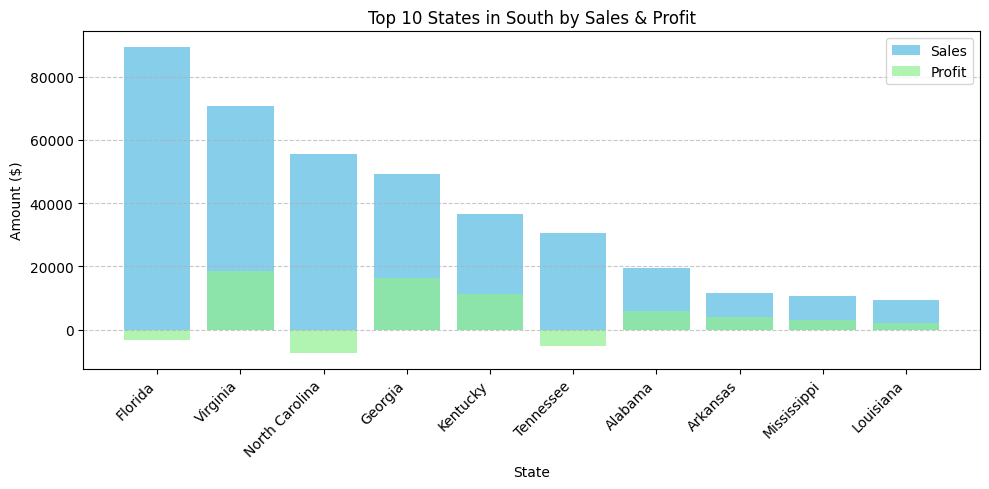

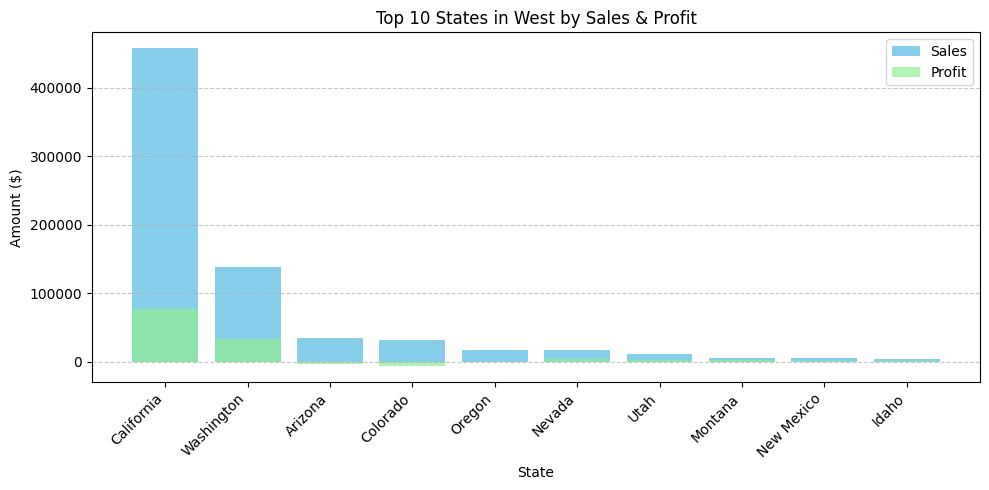

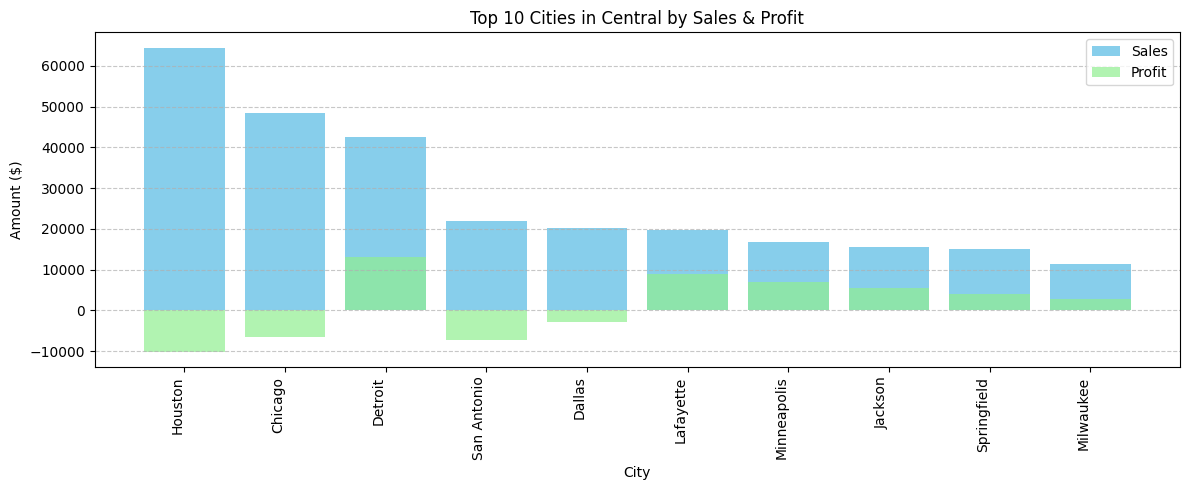

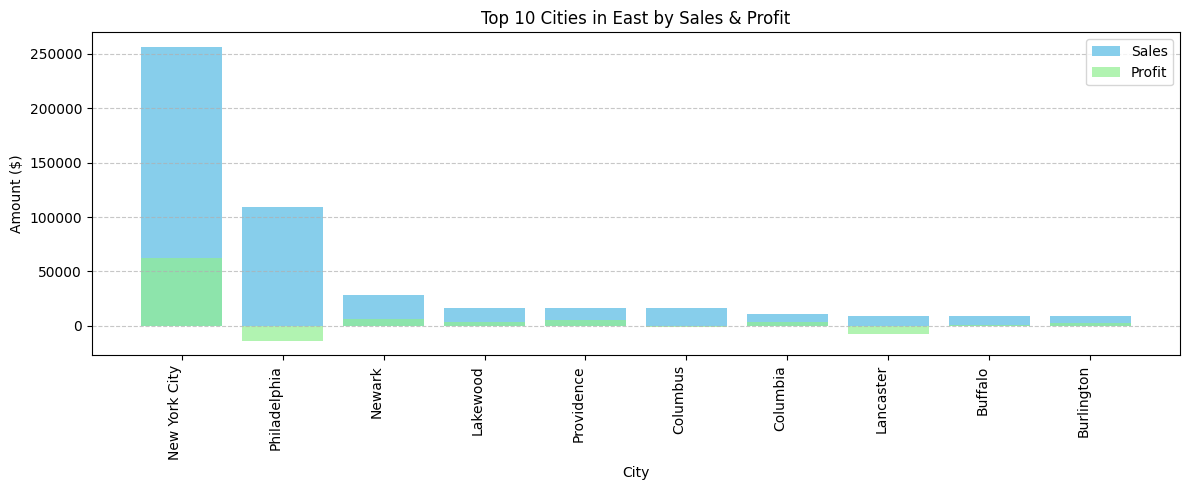

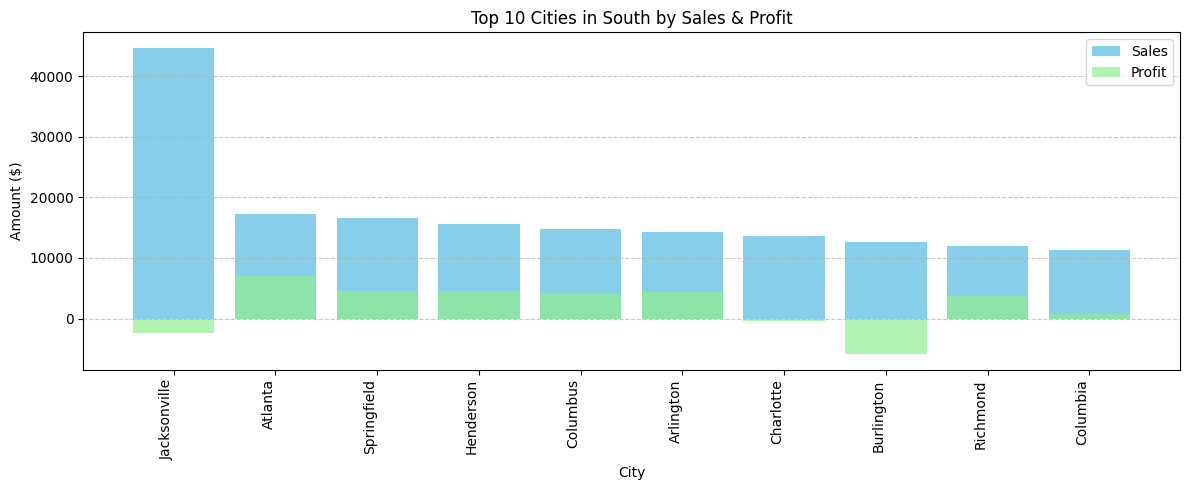

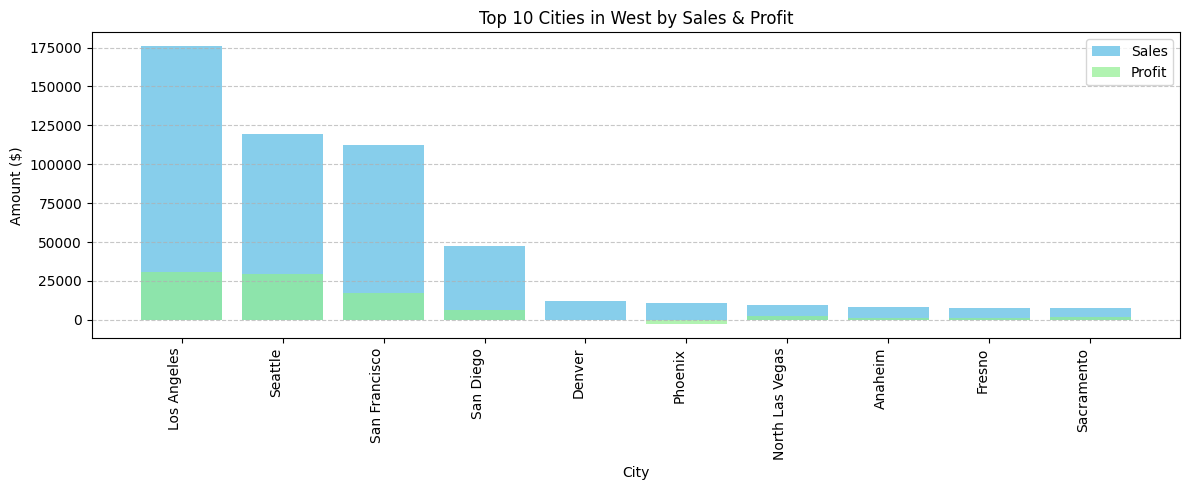

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Top 10 States per Region
# -----------------------------
top_states = (
    df.groupby(['Region', 'State'])[['Sales', 'Profit']]
      .sum()
      .reset_index()
      .sort_values(['Region', 'Sales'], ascending=[True, False])
      .groupby('Region').head(10)
)

print("=== Top 10 States by Sales per Region ===")
print(top_states)

# -----------------------------
# 2. Top 10 Cities per Region
# -----------------------------
top_cities = (
    df.groupby(['Region', 'City'])[['Sales', 'Profit']]
      .sum()
      .reset_index()
      .sort_values(['Region', 'Sales'], ascending=[True, False])
      .groupby('Region').head(10)
)

print("\n=== Top 10 Cities by Sales per Region ===")
print(top_cities)

# -----------------------------
# 3. Visualization: Top States per Region
# -----------------------------
for region in top_states['Region'].unique():
    data = top_states[top_states['Region'] == region]
    plt.figure(figsize=(10, 5))
    plt.bar(data['State'], data['Sales'], color='skyblue', label='Sales')
    plt.bar(data['State'], data['Profit'], color='lightgreen', alpha=0.7, label='Profit')
    plt.title(f'Top 10 States in {region} by Sales & Profit')
    plt.ylabel('Amount ($)')
    plt.xlabel('State')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4. Visualization: Top Cities per Region
# -----------------------------
for region in top_cities['Region'].unique():
    data = top_cities[top_cities['Region'] == region]
    plt.figure(figsize=(12, 5))
    plt.bar(data['City'], data['Sales'], color='skyblue', label='Sales')
    plt.bar(data['City'], data['Profit'], color='lightgreen', alpha=0.7, label='Profit')
    plt.title(f'Top 10 Cities in {region} by Sales & Profit')
    plt.ylabel('Amount ($)')
    plt.xlabel('City')
    plt.xticks(rotation=90, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


Sales & Profit by Category + Top Product per Category For Region


=== South Region: Sales & Profit by Category ===
          Category       Sales      Profit
2       Technology  148771.908  19991.8314
1  Office Supplies  125651.313  19986.3928
0        Furniture  117298.684   6771.2061

=== South Region: Top Product per Category ===
          Category                                        Top Product  \
0       Technology  Cisco TelePresence System EX90 Videoconferenci...   
1  Office Supplies         GBC DocuBind TL300 Electric Binding System   
2        Furniture  Chromcraft Bull-Nose Wood Oval Conference Tabl...   

       Sales  
0  22638.480  
1   8342.007  
2   6611.760  


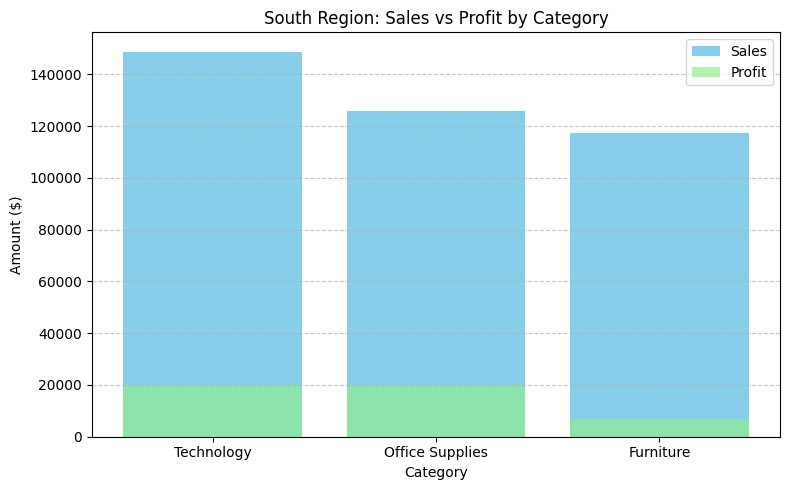


=== West Region: Sales & Profit by Category ===
          Category        Sales      Profit
0        Furniture  252612.7435  11504.9503
2       Technology  251991.8320  44303.6496
1  Office Supplies  220853.2490  52609.8490

=== West Region: Top Product per Category ===
          Category                                    Top Product     Sales
0        Furniture  Global Troy Executive Leather Low-Back Tilter  10019.60
1       Technology          Canon imageCLASS 2200 Advanced Copier  13999.96
2  Office Supplies    High Speed Automatic Electric Letter Opener  13100.24


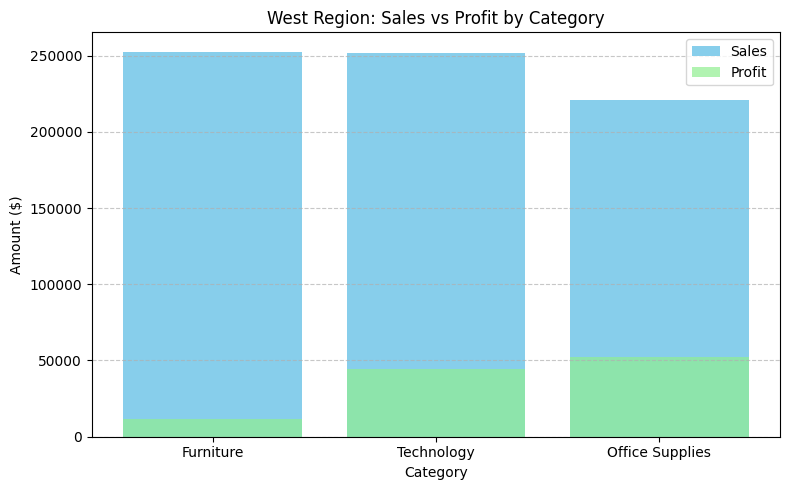


=== Central Region: Sales & Profit by Category ===
          Category        Sales      Profit
2       Technology  170416.3120  33697.4320
1  Office Supplies  167026.4150   8879.9799
0        Furniture  163797.1638  -2871.0494

=== Central Region: Top Product per Category ===
          Category                                   Top Product      Sales
0       Technology         Canon imageCLASS 2200 Advanced Copier  17499.950
1  Office Supplies          Ibico EPK-21 Electric Binding System  11339.940
2        Furniture  HON 5400 Series Task Chairs for Big and Tall   6939.702


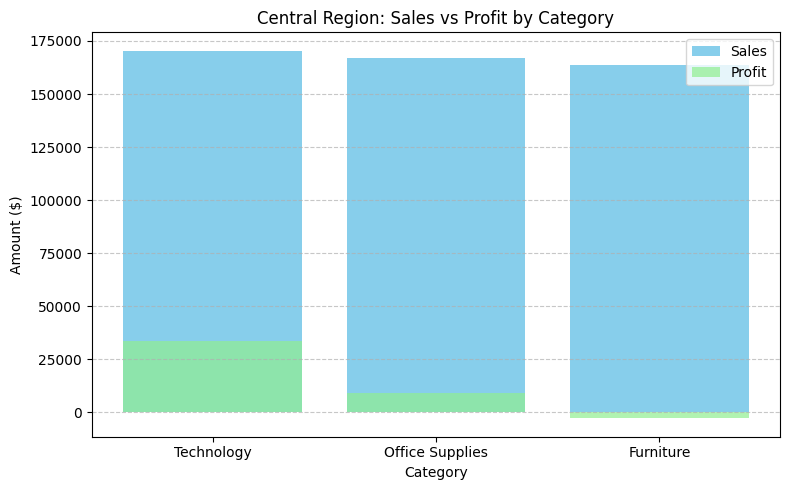


=== East Region: Sales & Profit by Category ===
          Category       Sales      Profit
2       Technology  264973.981  47462.0351
0        Furniture  208291.204   3046.1658
1  Office Supplies  205516.055  41014.5791

=== East Region: Top Product per Category ===
          Category                                        Top Product  \
0       Technology              Canon imageCLASS 2200 Advanced Copier   
1        Furniture  Riverside Palais Royal Lawyers Bookcase, Royal...   
2  Office Supplies         GBC DocuBind TL300 Electric Binding System   

       Sales  
0  30099.914  
1  11717.034  
2   8790.502  


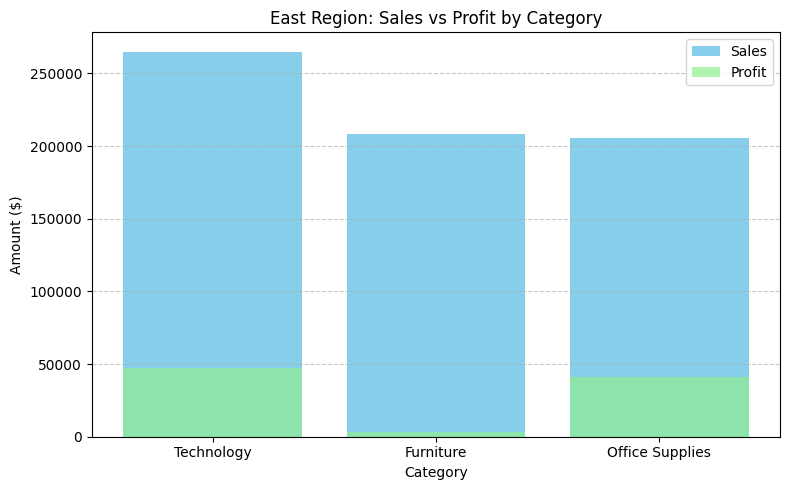

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Iterate through each Region
# -----------------------------
for region in df['Region'].unique():
    region_df = df[df['Region'] == region]

    # -----------------------------
    # 2. Aggregate Sales & Profit by Category
    # -----------------------------
    category_agg = (
        region_df.groupby('Category')[['Sales', 'Profit']]
        .sum()
        .reset_index()
        .sort_values(by='Sales', ascending=False)
    )
    print(f"\n=== {region} Region: Sales & Profit by Category ===")
    print(category_agg)

    # -----------------------------
    # 3. Top Product per Category
    # -----------------------------
    top_products_list = []
    for category in category_agg['Category']:
        product_agg = (
            region_df[region_df['Category'] == category]
            .groupby('Product Name')['Sales']
            .sum()
            .reset_index()
            .sort_values(by='Sales', ascending=False)
        )
        top_product = product_agg.iloc[0]
        top_products_list.append({
            'Category': category,
            'Top Product': top_product['Product Name'],
            'Sales': top_product['Sales']
        })

    top_products_df = pd.DataFrame(top_products_list)
    print(f"\n=== {region} Region: Top Product per Category ===")
    print(top_products_df)

    # -----------------------------
    # 4. Visualization: Category Sales vs Profit
    # -----------------------------
    plt.figure(figsize=(8, 5))
    plt.bar(category_agg['Category'], category_agg['Sales'], color='skyblue', label='Sales')
    plt.bar(category_agg['Category'], category_agg['Profit'], color='lightgreen', alpha=0.7, label='Profit')
    plt.title(f'{region} Region: Sales vs Profit by Category')
    plt.ylabel('Amount ($)')
    plt.xlabel('Category')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Sales & Profit by Category + Top Product per Category
For Top 10 States and Cities per Region

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Top 10 States per Region
# -----------------------------
top_states = (
    df.groupby(['Region', 'State'])[['Sales', 'Profit']]
      .sum()
      .reset_index()
      .sort_values(['Region', 'Sales'], ascending=[True, False])
      .groupby('Region').head(10)
)

# -----------------------------
# 2. Top 10 Cities per Region
# -----------------------------
top_cities = (
    df.groupby(['Region', 'City'])[['Sales', 'Profit']]
      .sum()
      .reset_index()
      .sort_values(['Region', 'Sales'], ascending=[True, False])
      .groupby('Region').head(10)
)

# -----------------------------
# 3. Analysis by Top States
# -----------------------------
for idx, row in top_states.iterrows():
    region = row['Region']
    state = row['State']
    state_df = df[(df['Region'] == region) & (df['State'] == state)]

    # Category aggregation
    category_agg = state_df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
    category_agg = category_agg.sort_values(by='Sales', ascending=False)
    
    # Top product per category
    top_products_list = []
    for category in category_agg['Category']:
        prod_df = state_df[state_df['Category'] == category].groupby('Product Name')['Sales'].sum().reset_index()
        top_prod = prod_df.sort_values(by='Sales', ascending=False).iloc[0]
        top_products_list.append({
            'Category': category,
            'Top Product': top_prod['Product Name'],
            'Sales': top_prod['Sales']
        })
    top_products_df = pd.DataFrame(top_products_list)
    
    # Print results
    print(f"\n=== Region: {region} | State: {state} ===")
    print("Category Sales & Profit:\n", category_agg)
    print("Top Product per Category:\n", top_products_df)

# -----------------------------
# 4. Analysis by Top Cities
# -----------------------------
for idx, row in top_cities.iterrows():
    region = row['Region']
    city = row['City']
    city_df = df[(df['Region'] == region) & (df['City'] == city)]

    # Category aggregation
    category_agg = city_df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
    category_agg = category_agg.sort_values(by='Sales', ascending=False)
    
    # Top product per category
    top_products_list = []
    for category in category_agg['Category']:
        prod_df = city_df[city_df['Category'] == category].groupby('Product Name')['Sales'].sum().reset_index()
        top_prod = prod_df.sort_values(by='Sales', ascending=False).iloc[0]
        top_products_list.append({
            'Category': category,
            'Top Product': top_prod['Product Name'],
            'Sales': top_prod['Sales']
        })
    top_products_df = pd.DataFrame(top_products_list)
    
    # Print results
    print(f"\n=== Region: {region} | City: {city} ===")
    print("Category Sales & Profit:\n", category_agg)
    print("Top Product per Category:\n", top_products_df)



=== Region: Central | State: Texas ===
Category Sales & Profit:
           Category       Sales      Profit
2       Technology  65104.2240   3291.4290
0        Furniture  60593.2918 -10436.1419
1  Office Supplies  44490.5300 -18584.6434
Top Product per Category:
           Category                                   Top Product      Sales
0       Technology     Lexmark MX611dhe Monochrome Laser Printer  11219.934
1        Furniture  HON 5400 Series Task Chairs for Big and Tall   3434.802
2  Office Supplies   High Speed Automatic Electric Letter Opener   3930.072

=== Region: Central | State: Illinois ===
Category Sales & Profit:
           Category      Sales     Profit
2       Technology  31983.673  4822.5592
0        Furniture  28274.522 -9076.2894
1  Office Supplies  19907.906 -8354.1568
Top Product per Category:
           Category                                 Top Product     Sales
0       Technology                           Samsung Galaxy S4  3004.752
1        Furniture  Guest

Treemap: Sales by Category — Top 5 States & Cities per Region

Bubble Plot: Top Categories by Profit Impact

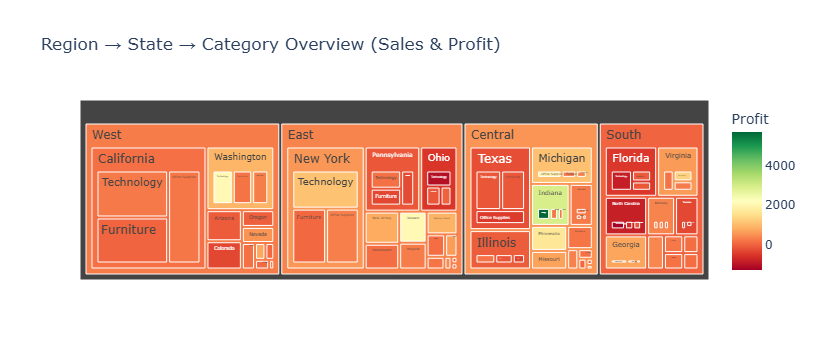

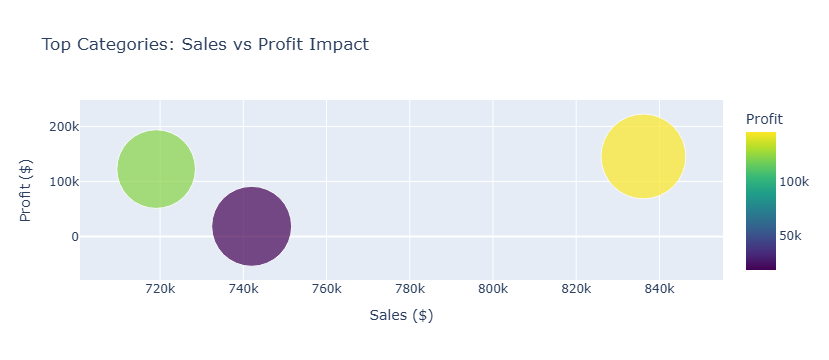

In [60]:
import plotly.express as px

# -----------------------------
# 7. Treemap: Region → State → Category
# -----------------------------
fig_treemap = px.treemap(
    df,
    path=['Region', 'State', 'Category'],
    values='Sales',
    color='Profit',
    color_continuous_scale='RdYlGn',
    hover_data={'Sales': True, 'Profit': True, 'Category': True},
    title='Region → State → Category Overview (Sales & Profit)'
)
fig_treemap.update_traces(root_color="lightgrey")
fig_treemap.show()

# -----------------------------
# 8. Bubble Plot: Top Categories by Profit Impact
# -----------------------------
category_summary = (
    df.groupby('Category')[['Sales', 'Profit']]
      .sum()
      .reset_index()
      .sort_values('Profit', ascending=False)
)

fig_bubble = px.scatter(
    category_summary,
    x='Sales',
    y='Profit',
    size='Sales',
    color='Profit',
    hover_name='Category',
    size_max=60,
    color_continuous_scale='Viridis',
    title='Top Categories: Sales vs Profit Impact'
)
fig_bubble.update_layout(xaxis_title='Sales ($)', yaxis_title='Profit ($)')
fig_bubble.show()


Sunburst Category → Sub-Category Sales & Profit Sunburst

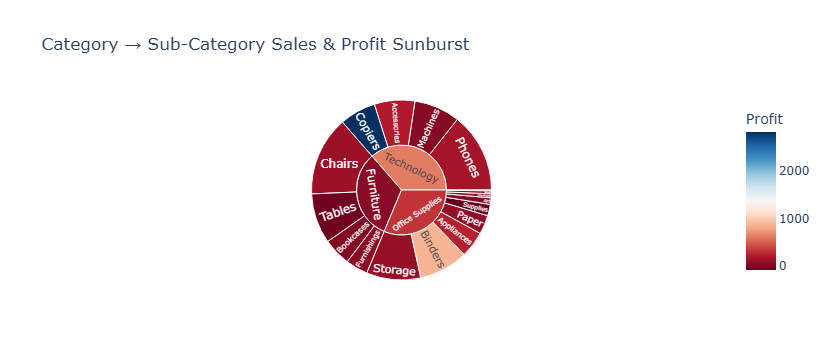

In [64]:
sunburst_fig = px.sunburst(
    df,
    path=['Category', 'Sub-Category'],
    values='Sales',
    color='Profit',
    color_continuous_scale='RdBu',
    title='Category → Sub-Category Sales & Profit Sunburst'
)
sunburst_fig.show()


In [79]:
# Count unique sub-categories
total_subcategories = df['Sub-Category'].nunique()
print(f"Total Sub-Categories: {total_subcategories}")

# Optional: List all sub-categories per Category
subcategories_per_category = df.groupby('Category')['Sub-Category'].unique().reset_index()
print(subcategories_per_category)


Total Sub-Categories: 17
          Category                                       Sub-Category
0        Furniture           [Bookcases, Chairs, Tables, Furnishings]
1  Office Supplies  [Labels, Storage, Art, Binders, Appliances, Pa...
2       Technology           [Phones, Accessories, Machines, Copiers]


Top 10 products per category based on Sales

In [69]:
# Top 10 products per category based on Sales
top_products_per_category = (
    df.groupby(['Category', 'Product Name'])['Sales']
      .sum()
      .reset_index()
      .sort_values(['Category', 'Sales'], ascending=[True, False])
      .groupby('Category')
      .head(10)  # top 10 products per category
)

# Display the result
top_products_per_category


,Category,Product Name,Sales
206,Furniture,HON 5400 Series Task Chairs for Big and Tall,21870.5760
321,Furniture,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.9656
40,Furniture,Bretford Rectangular Conference Table Tops,12995.2915
201,Furniture,Global Troy Executive Leather Low-Back Tilter,12975.3820
325,Furniture,SAFCO Arco Folding Chair,11572.7800
89,Furniture,DMI Eclipse Executive Suite Bookcases,11046.6090
225,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",10637.5280
63,Furniture,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.6400
42,Furniture,Bush Advantage Collection Racetrack Conference...,9544.7250
205,Furniture,GuestStacker Chair with Chrome Finish Legs,9070.9440


Treemap for top products in each category

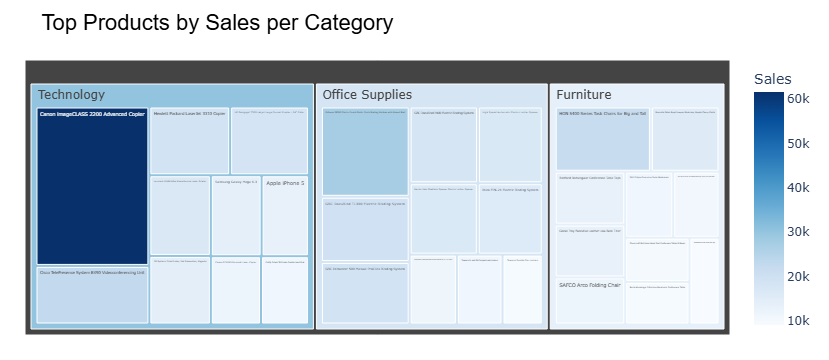

In [78]:
import plotly.express as px

# Treemap for top products in each category with muted blue color
fig = px.treemap(
    top_products_per_category,  # your dataframe
    path=['Category', 'Product Name'],  # hierarchy: Category → Product
    values='Sales',  # size by sales
    color='Sales',  # color by sales
    color_continuous_scale='Blues',  # sober blue scale
    hover_data=['Sales'],
    title='Top Products by Sales per Category'
)

# Layout tweaks for clean, professional look
fig.update_layout(
    margin=dict(t=60, l=25, r=25, b=25),
    title_font=dict(size=22, family='Arial', color='black'),
)

# Format hover data nicely
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Sales: $%{value:,.2f}<extra></extra>'
)

fig.show()


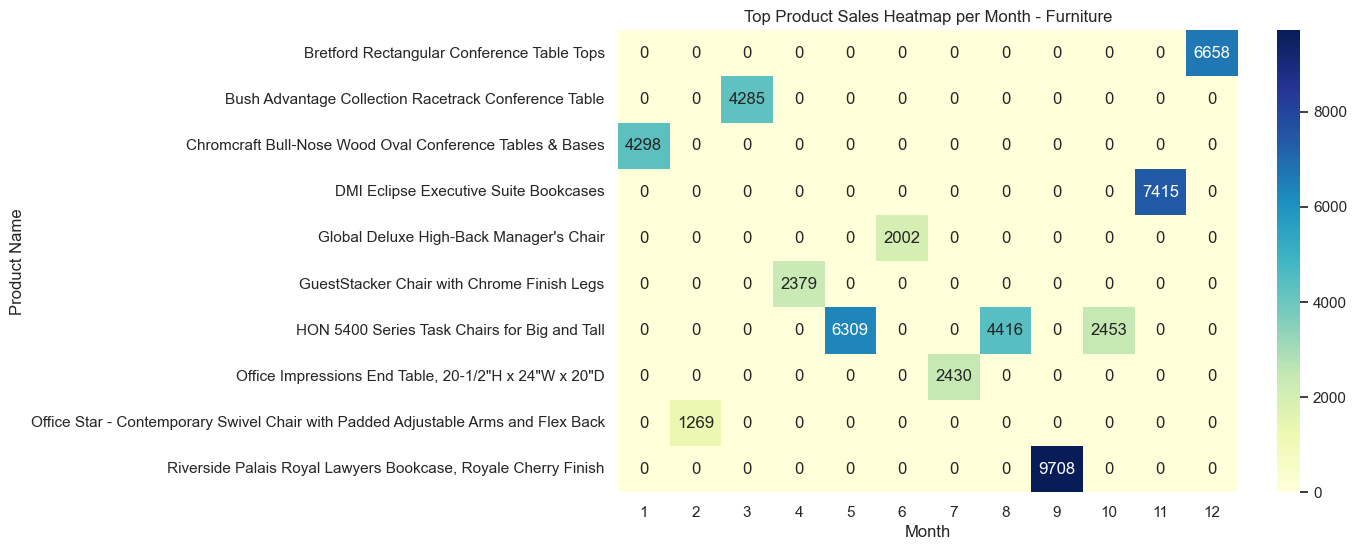

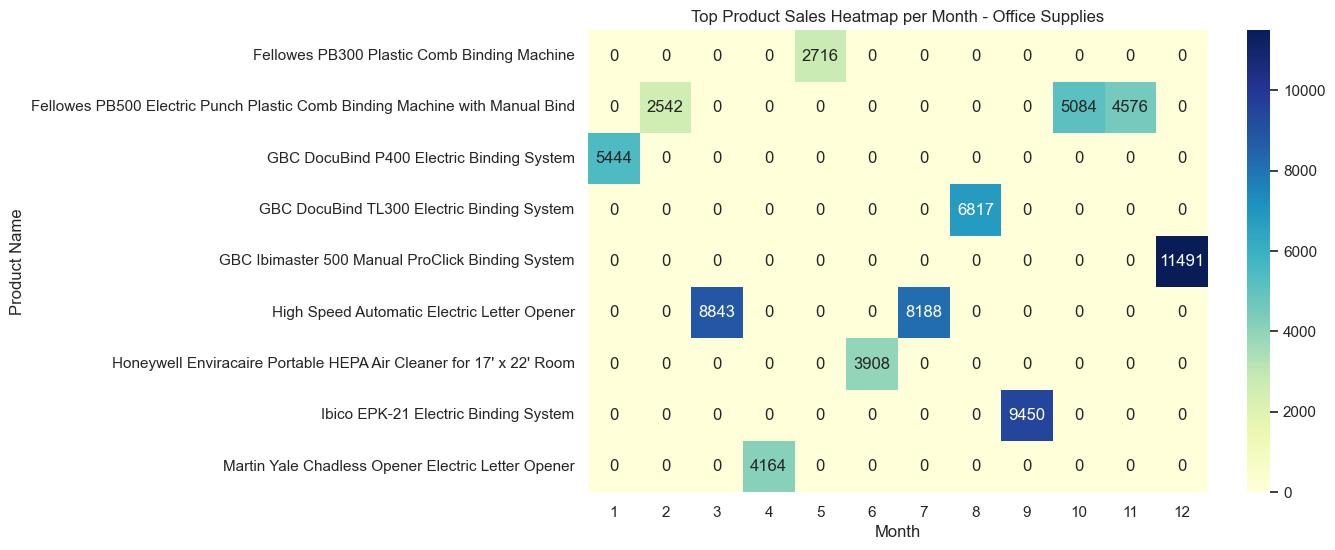

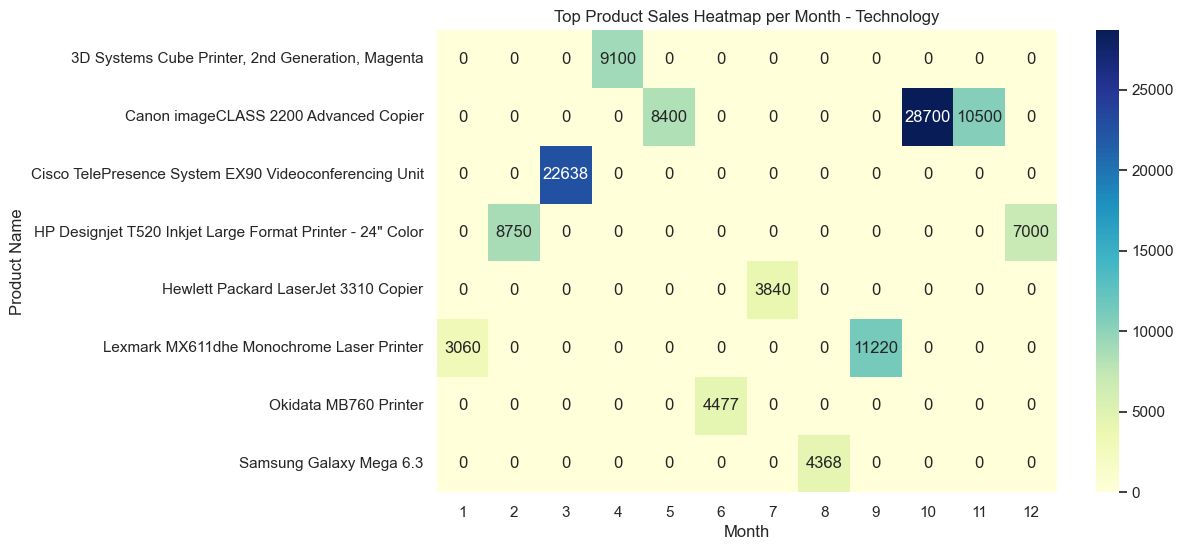

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Ensure Order Date is datetime and extract year & month
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month'] = df['Order Date'].dt.month

# ==========================
# Top Products per Category per Month (Heatmap)
# ==========================
top_products = df.groupby(['Category','month','Product Name'], observed=True)['Sales'].sum().reset_index()
top_products = top_products.sort_values(['Category','month','Sales'], ascending=[True,True,False])
top_products = top_products.groupby(['Category','month'], observed=True).head(1).reset_index(drop=True)

categories = df['Category'].unique()
for cat in categories:
    cat_data = top_products[top_products['Category'] == cat]
    
    # Pivot for heatmap: Product Name vs Month
    heatmap_data = cat_data.pivot(index='Product Name', columns='month', values='Sales').fillna(0)
    
    plt.figure(figsize=(10,6))
    sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlGnBu')
    plt.title(f'Top Product Sales Heatmap per Month - {cat}')
    plt.ylabel('Product Name')
    plt.xlabel('Month')
    plt.show()
